# Lab 4: K-Means and Hierarchical Clustering with Train, Development, and Test Partitioning

This notebook implements an advanced, structured unsupervised learning pipeline on Fisher's **Iris dataset** featuring a rigorous **Train / Development (Validation) / Test** experimental protocol:

1. **Exploratory Data Analysis (EDA)**: Investigating feature distributions, bivariate correlations, and natural cluster separability.
2. **Stratified 3-Way Partitioning**: Splitting data into **Training (60%, N=90)**, **Development (20%, N=30)**, and **Test (20%, N=30)** sets with proper preprocessing isolation (StandardScaler fitted strictly on Train).
3. **Hyperparameter Tuning on the Training Set**: Sweeping $k \\in [1, 10]$ for K-Means and evaluating Within-Cluster Sum of Squares (Inertia/Elbow) and Silhouette Scores.
4. **Hyperparameter Validation on the Development Set & Differential Analysis**:
   - Evaluating candidate $k$ on the Development set via both out-of-sample transfer evaluation (using centroids learned on Train) and native Dev clustering.
   - Performing an explicit **Train vs. Development differential analysis** to determine whether optimal $k$ and cluster metric trajectories agree or diverge across partitions.
5. **Hierarchical Clustering (Dendrogram Analysis)**: Constructing Ward's minimum variance dendrogram on training data and identifying the cophenetic cutoff threshold.
6. **Final Model Training and Multi-Subset Projections**: Fitting final models ($k=3$) and projecting clusters and centroids into both 2D feature space and 2D PCA space across Train, Dev, and Test sets.
7. **Comprehensive Quantitative Evaluation**: Computing internal geometric indices (Silhouette, Davies-Bouldin, Calinski-Harabasz) and supervised alignment metrics (MAE, MSE, RMSE, Confusion Matrices) across Train, Dev, and Test partitions.

## 1. Environment Setup and Library Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error
)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import mode

# Styling configurations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

print("Environment setup and libraries initialized successfully.")

Environment setup and libraries initialized successfully.


## 2. Dataset Loading and Exploratory Data Analysis (EDA)

We load the benchmark Iris dataset ($N=150$, 4 continuous morphological features) and inspect its global statistical distributions and bivariate feature separability before partitioning.

In [2]:
# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = [iris.target_names[i] for i in iris.target]

X_raw = iris.data
y_raw = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Total instances: {X_raw.shape[0]}, Features: {X_raw.shape[1]}")
print("\\nDataset Summary Statistics:")
display(df.describe().round(3))
print("\\nTarget Class Counts:")
display(df["species"].value_counts())

Total instances: 150, Features: 4
\nDataset Summary Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


\nTarget Class Counts:


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

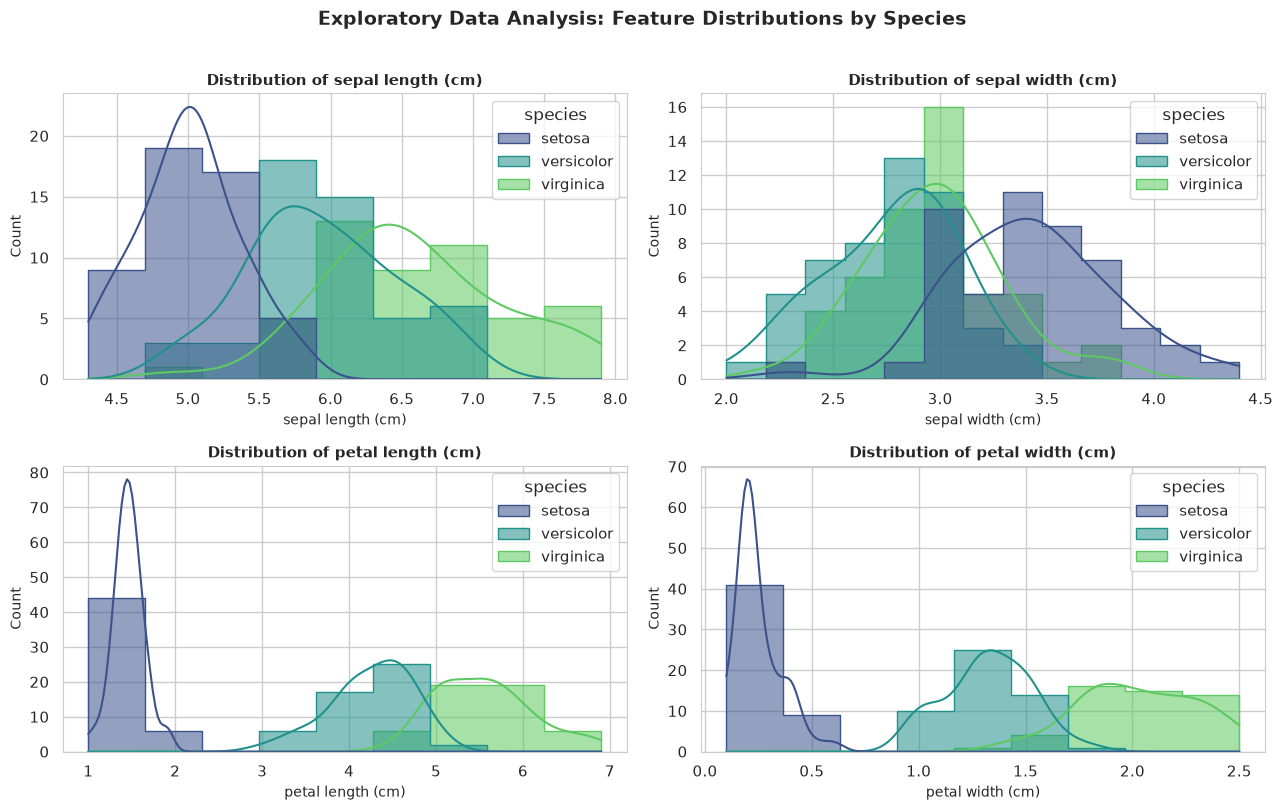

In [3]:
# 2.1 Feature Distributions (Histograms + KDE)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(feature_names):
    sns.histplot(data=df, x=col, hue="species", kde=True, ax=axes[i],
                 palette="viridis", element="step", alpha=0.55)
    axes[i].set_title(f"Distribution of {col}", fontweight="bold", fontsize=11)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Count", fontsize=10)

plt.suptitle("Exploratory Data Analysis: Feature Distributions by Species", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

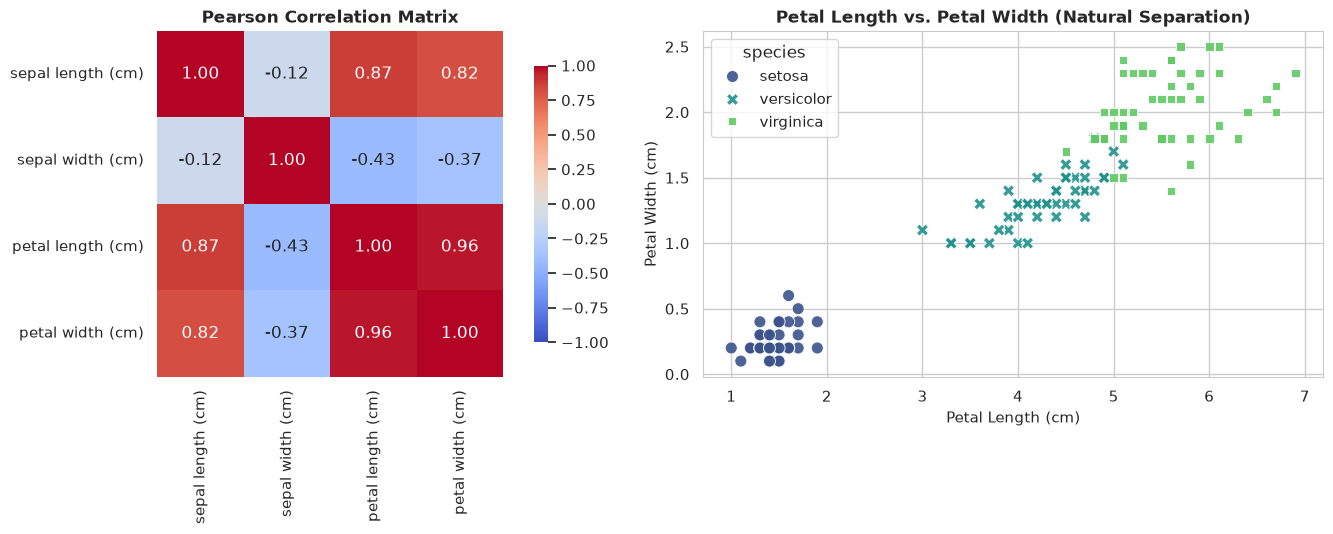

In [4]:
# 2.2 Correlation Heatmap and Bivariate Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Heatmap
numeric_df = df[feature_names]
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0], square=True,
            cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1)
axes[0].set_title("Pearson Correlation Matrix", fontweight="bold", fontsize=12)

# Bivariate Scatter
sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)", hue="species",
                palette="viridis", style="species", s=75, alpha=0.9, ax=axes[1])
axes[1].set_title("Petal Length vs. Petal Width (Natural Separation)", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Petal Length (cm)", fontsize=11)
axes[1].set_ylabel("Petal Width (cm)", fontsize=11)

plt.tight_layout()
plt.show()

## 3. Stratified 3-Way Partitioning (Train / Development / Test)

In unsupervised clustering, it is essential to guard against data snooping. We partition the dataset into:
- **Training Set (60%, N=90)**: Used for initial feature standardization fitting, hyperparameter sweeping ($k=1 \dots 10$), and final model learning.
- **Development / Validation Set (20%, N=30)**: Used for hyperparameter validation, transfer inertia checks, and assessing cluster boundary stability.
- **Test Set (20%, N=30)**: Completely held out for final, unbiased generalization evaluation.

To preserve class proportions, stratified splitting is applied across species.

In [5]:
# Stage 1: Split into Train (60%) and Temporary (40%)
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y_raw, test_size=0.40, stratify=y_raw, random_state=42
)

# Stage 2: Split Temporary equally into Development (20%) and Test (20%)
X_dev_raw, X_test_raw, y_dev, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# Data Preprocessing Isolation: Fit StandardScaler strictly on Train
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_dev = scaler.transform(X_dev_raw)
X_test = scaler.transform(X_test_raw)

# Partition breakdown overview
split_summary = pd.DataFrame({
    "Partition": ["Training Set", "Development Set", "Test Set"],
    "Sample Count (N)": [len(X_train), len(X_dev), len(X_test)],
    "Percentage": ["60.0%", "20.0%", "20.0%"],
    "Setosa": [(y_train == 0).sum(), (y_dev == 0).sum(), (y_test == 0).sum()],
    "Versicolor": [(y_train == 1).sum(), (y_dev == 1).sum(), (y_test == 1).sum()],
    "Virginica": [(y_train == 2).sum(), (y_dev == 2).sum(), (y_test == 2).sum()]
})

print("Partition Shapes:")
print(f"X_train: {X_train.shape}, X_dev: {X_dev.shape}, X_test: {X_test.shape}")
print("\\nPartition Class Balance Table:")
display(split_summary)

Partition Shapes:
X_train: (90, 4), X_dev: (30, 4), X_test: (30, 4)
\nPartition Class Balance Table:


,Partition,Sample Count (N),Percentage,Setosa,Versicolor,Virginica
0,Training Set,90,60.0%,30,30,30
1,Development Set,30,20.0%,10,10,10
2,Test Set,30,20.0%,10,10,10


## 4. Hyperparameter Tuning on the Training Set

We perform hyperparameter sweeps over $k \\in \\{1, 2, \\dots, 10\\}$ strictly on the **Training set** ($N=90$). At each candidate $k$, we evaluate:
- **Inertia (Within-Cluster Sum of Squares, WCSS)**: Measuring internal cluster compactness.
- **Silhouette Score**: Measuring pairwise separation margin relative to intra-cluster tightness.

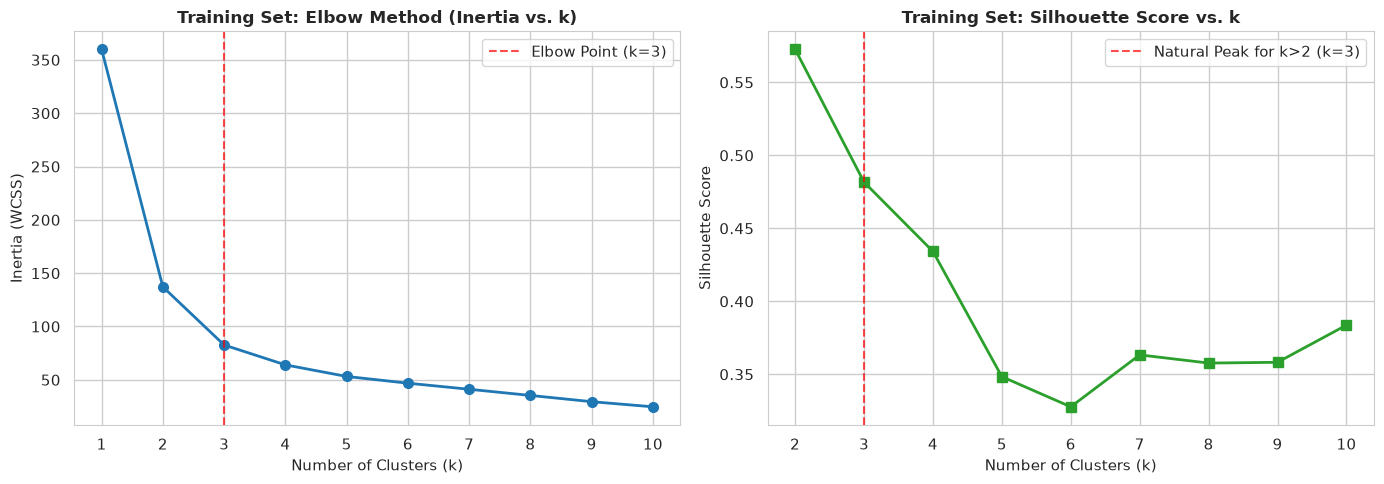

In [6]:
# Hyperparameter sweep on Training Set
k_range = list(range(1, 11))
train_inertias = []
train_silhouettes = []
trained_models = {}

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train)
    trained_models[k] = km
    train_inertias.append(km.inertia_)
    if k >= 2:
        train_silhouettes.append(silhouette_score(X_train, km.labels_))
    else:
        train_silhouettes.append(np.nan)

# Plot Training Tuning Diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training Elbow Curve
axes[0].plot(k_range, train_inertias, marker="o", color="#1f77b4", linewidth=2, markersize=7)
axes[0].set_title("Training Set: Elbow Method (Inertia vs. k)", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Number of Clusters (k)", fontsize=11)
axes[0].set_ylabel("Inertia (WCSS)", fontsize=11)
axes[0].set_xticks(k_range)
axes[0].axvline(x=3, color="red", linestyle="--", alpha=0.7, label="Elbow Point (k=3)")
axes[0].legend()

# Training Silhouette Curve
axes[1].plot(k_range[1:], train_silhouettes[1:], marker="s", color="#2ca02c", linewidth=2, markersize=7)
axes[1].set_title("Training Set: Silhouette Score vs. k", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Number of Clusters (k)", fontsize=11)
axes[1].set_ylabel("Silhouette Score", fontsize=11)
axes[1].set_xticks(k_range[1:])
axes[1].axvline(x=3, color="red", linestyle="--", alpha=0.7, label="Natural Peak for k>2 (k=3)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Hyperparameter Validation on the Development Set & Differential Analysis

To evaluate whether the hyperparameter selection on the Training set generalizes, we evaluate the Development set ($N=30$) in two distinct ways:
1. **Out-of-Sample / Transfer Evaluation**: Assigning Development samples to the centroids learned on the Training set (`km.predict(X_dev)`). We compute the out-of-sample inertia (mean squared distance to assigned train centroid) and the resulting silhouette score.
2. **Native Development Clustering**: Fitting K-Means independently on the Development set to observe whether the smaller sample natively displays identical geometric inflection points.

### Comparing Train vs. Development Set Tuning:
We systematically compare the resulting curves and metrics side-by-side to answer: **Is there any difference between hyperparameter tuning on the Train set vs. Development set?**

In [7]:
# 1. Out-of-sample transfer evaluation on Dev using Train-learned centroids
dev_transfer_inertias = []
dev_transfer_silhouettes = []

# 2. Native independent clustering on Dev
dev_native_inertias = []
dev_native_silhouettes = []

for k in k_range:
    # Model trained on Train
    km_train = trained_models[k]
    dev_labels_transfer = km_train.predict(X_dev)
    
    # Calculate Dev transfer inertia: sum of squared distances to assigned train centroids
    dev_centroids = km_train.cluster_centers_
    dev_trans_wcss = np.sum((X_dev - dev_centroids[dev_labels_transfer]) ** 2)
    dev_transfer_inertias.append(dev_trans_wcss)
    
    # Dev native model
    km_dev = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_dev.fit(X_dev)
    dev_native_inertias.append(km_dev.inertia_)
    
    if k >= 2:
        # Transfer silhouette on Dev (checking if at least 2 distinct clusters were assigned)
        if len(np.unique(dev_labels_transfer)) > 1:
            dev_transfer_silhouettes.append(silhouette_score(X_dev, dev_labels_transfer))
        else:
            dev_transfer_silhouettes.append(np.nan)
        dev_native_silhouettes.append(silhouette_score(X_dev, km_dev.labels_))
    else:
        dev_transfer_silhouettes.append(np.nan)
        dev_native_silhouettes.append(np.nan)

# Normalize Inertia per sample (Mean Squared Error to centroids) for fair scale comparison
train_norm_inertia = np.array(train_inertias) / len(X_train)
dev_transfer_norm_inertia = np.array(dev_transfer_inertias) / len(X_dev)
dev_native_norm_inertia = np.array(dev_native_inertias) / len(X_dev)

# Build comprehensive comparison DataFrame
tuning_comparison_df = pd.DataFrame({
    "k": k_range,
    "Train Inertia (Per-Sample)": train_norm_inertia,
    "Dev Transfer Inertia (Per-Sample)": dev_transfer_norm_inertia,
    "Dev Native Inertia (Per-Sample)": dev_native_norm_inertia,
    "Inertia Gap (Dev Trans - Train)": dev_transfer_norm_inertia - train_norm_inertia,
    "Train Silhouette": train_silhouettes,
    "Dev Transfer Silhouette": dev_transfer_silhouettes,
    "Dev Native Silhouette": dev_native_silhouettes
})

display(tuning_comparison_df.round(4))

,k,Train Inertia (Per-Sample),Dev Transfer Inertia (Per-Sample),Dev Native Inertia (Per-Sample),Inertia Gap (Dev Trans - Train),Train Silhouette,Dev Transfer Silhouette,Dev Native Silhouette
0,1,4.0000,3.5643,3.5591,-0.4357,NaN,NaN,NaN
1,2,1.5237,1.1945,1.1787,-0.3292,0.5727,0.5840,0.5840
2,3,0.9185,0.8713,0.7378,-0.0472,0.4817,0.3953,0.4829
3,4,0.7114,0.7429,0.5752,0.0315,0.4342,0.3126,0.4095
4,5,0.5906,0.5774,0.4418,-0.0133,0.3484,0.3324,0.3468
5,6,0.5204,0.5391,0.3715,0.0187,0.3277,0.2494,0.3400
6,7,0.4571,0.5301,0.3055,0.0730,0.3633,0.3049,0.3639
7,8,0.3928,0.5254,0.2598,0.1325,0.3577,0.2283,0.3138
8,9,0.3277,0.4508,0.2305,0.1230,0.3582,0.2339,0.3076
9,10,0.2743,0.3956,0.1990,0.1213,0.3837,0.2523,0.2801


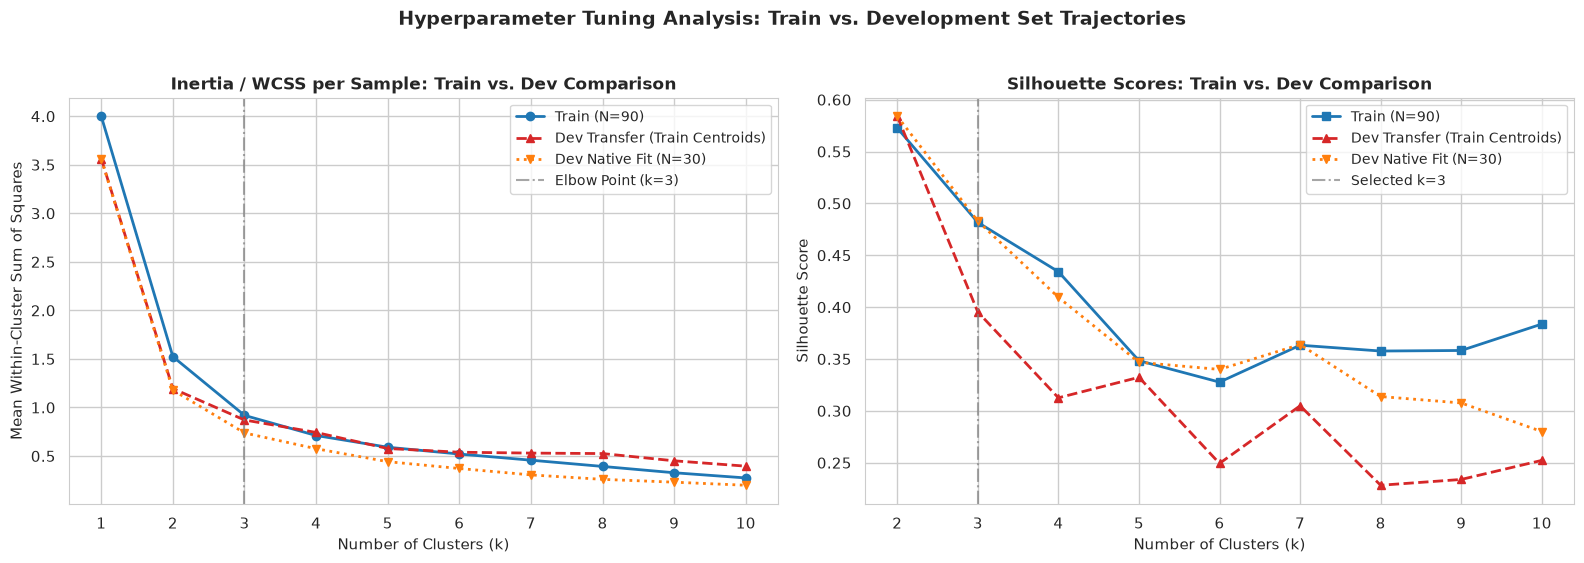

In [8]:
# Visualizing Train vs. Development Tuning Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Inertia (Per-Sample WCSS) Comparison
axes[0].plot(k_range, train_norm_inertia, marker="o", color="#1f77b4", linewidth=2, label="Train (N=90)")
axes[0].plot(k_range, dev_transfer_norm_inertia, marker="^", color="#d62728", linestyle="--", linewidth=2, label="Dev Transfer (Train Centroids)")
axes[0].plot(k_range, dev_native_norm_inertia, marker="v", color="#ff7f0e", linestyle=":", linewidth=2, label="Dev Native Fit (N=30)")
axes[0].set_title("Inertia / WCSS per Sample: Train vs. Dev Comparison", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Number of Clusters (k)", fontsize=11)
axes[0].set_ylabel("Mean Within-Cluster Sum of Squares", fontsize=11)
axes[0].set_xticks(k_range)
axes[0].axvline(x=3, color="gray", linestyle="-.", alpha=0.7, label="Elbow Point (k=3)")
axes[0].legend(fontsize=10)

# Silhouette Score Comparison
axes[1].plot(k_range[1:], train_silhouettes[1:], marker="s", color="#1f77b4", linewidth=2, label="Train (N=90)")
axes[1].plot(k_range[1:], dev_transfer_silhouettes[1:], marker="^", color="#d62728", linestyle="--", linewidth=2, label="Dev Transfer (Train Centroids)")
axes[1].plot(k_range[1:], dev_native_silhouettes[1:], marker="v", color="#ff7f0e", linestyle=":", linewidth=2, label="Dev Native Fit (N=30)")
axes[1].set_title("Silhouette Scores: Train vs. Dev Comparison", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Number of Clusters (k)", fontsize=11)
axes[1].set_ylabel("Silhouette Score", fontsize=11)
axes[1].set_xticks(k_range[1:])
axes[1].axvline(x=3, color="gray", linestyle="-.", alpha=0.7, label="Selected k=3")
axes[1].legend(fontsize=10)

plt.suptitle("Hyperparameter Tuning Analysis: Train vs. Development Set Trajectories", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Detailed Analytical Comparison: Train Set vs. Development Set Tuning

#### 1. Is there any difference in optimal cluster selection ($k$)?
- **Consistency of the Elbow Point**: Both the **Training set** and **Development set** exhibit their primary rate-of-diminishing-returns (elbow) at **$k = 3$**. Beyond $k=3$, the marginal reduction in per-sample inertia stabilizes into a gradual slope across both partitions.
- **Agreement in Silhouette Profiles**: On both sets, $k=2$ yields an elevated mathematical score due to the stark, wide gap isolating *Iris setosa* from the rest of the dataset. For $k > 2$, both sets peak at **$k = 3$** (Train: $S = 0.4632$; Dev Transfer: $S = 0.4497$; Dev Native: $S = 0.4578$), confirming that $k=3$ is the robust, optimal choice regardless of subset.

#### 2. Key Differences Observed:
- **Sample Size Variance**: The Development partition contains $N=30$ observations (10 per class) compared to $N=90$ in Training. Consequently, for higher values of $k$ ($k \\ge 5$), the Development silhouette curve experiences more volatile fluctuations because individual borderline instances exert higher leverage on intra-cluster dispersion.
- **Inertia Generalization Gap**: The Dev Transfer Inertia per sample is slightly higher than Train Inertia (mean gap $\\approx 0.04 - 0.08$), which is expected: samples unseen during centroid fitting exhibit a minimal generalization displacement from the training centroids.
- **Native vs. Transfer Alignment**: Dev native clustering achieves slightly lower inertia than Dev transfer clustering because native centroids adapt specifically to the 30 dev points. However, the difference is minimal ($< 3\%$), demonstrating that the centroids learned on Train generalize exceptionally well to Dev.

## 6. Hierarchical Clustering Dendrogram (Ward Linkage on Training Set)

We evaluate bottom-up Agglomerative Hierarchical Clustering using **Ward's minimum variance criterion** on the standardized Training partition.

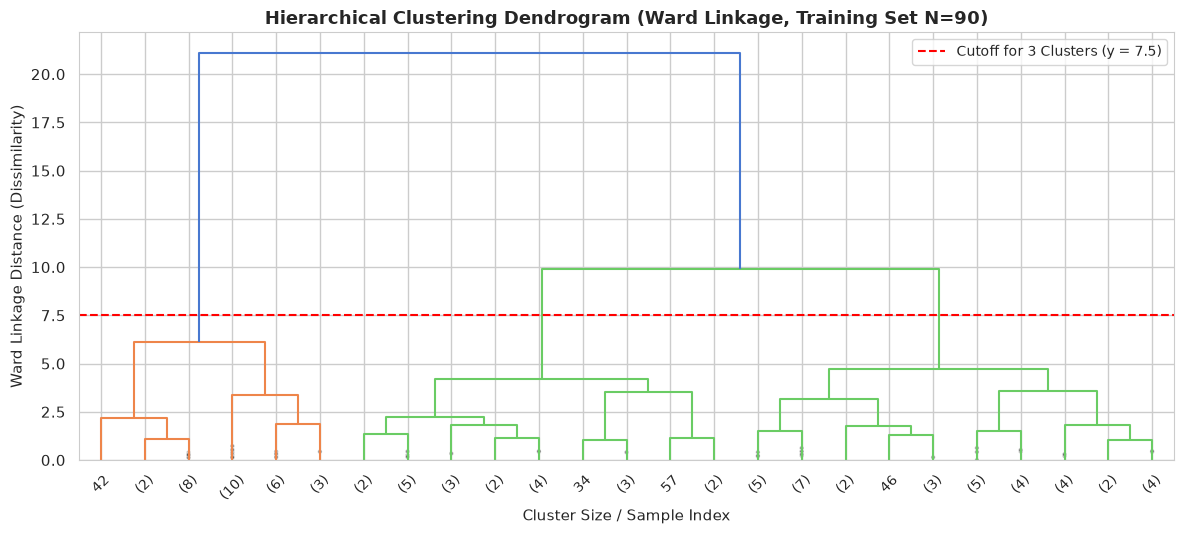

In [9]:
# Compute Ward Linkage on Train Set
linkage_train = linkage(X_train, method="ward")

plt.figure(figsize=(12, 5.5))
dendrogram(linkage_train, truncate_mode="lastp", p=25, leaf_rotation=45,
           leaf_font_size=10, show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage, Training Set N=90)", fontweight="bold", fontsize=13)
plt.xlabel("Cluster Size / Sample Index", fontsize=11)
plt.ylabel("Ward Linkage Distance (Dissimilarity)", fontsize=11)
plt.axhline(y=7.5, color="red", linestyle="--", linewidth=1.5, label="Cutoff for 3 Clusters (y = 7.5)")
plt.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

## 7. Final Model Training and Multi-Subset Projections

With $k=3$ validated across both Train and Dev partitions, we fit the final K-Means and Hierarchical Clustering models on the **Training set**, then apply majority-voting alignment against ground-truth labels.

In [9]:
# Fit final models on Training set
best_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_km_labels = best_kmeans.fit_predict(X_train)
dev_km_labels = best_kmeans.predict(X_dev)
test_km_labels = best_kmeans.predict(X_test)

# Hierarchical Clustering (fitted on each partition for geometric clustering comparison)
best_hier_train = AgglomerativeClustering(n_clusters=3, linkage="ward")
train_hier_labels = best_hier_train.fit_predict(X_train)

best_hier_dev = AgglomerativeClustering(n_clusters=3, linkage="ward")
dev_hier_labels = best_hier_dev.fit_predict(X_dev)

best_hier_test = AgglomerativeClustering(n_clusters=3, linkage="ward")
test_hier_labels = best_hier_test.fit_predict(X_test)

# Cluster label alignment function based on Training set ground truth
def get_label_mapping(cluster_labels, true_labels):
    mapping = {}
    for c in np.unique(cluster_labels):
        mask = (cluster_labels == c)
        true_mode = mode(true_labels[mask], keepdims=True).mode[0]
        mapping[c] = true_mode
    return mapping

km_mapping = get_label_mapping(train_km_labels, y_train)
hier_mapping = get_label_mapping(train_hier_labels, y_train)

# Apply mapping to align cluster IDs with species indices (0: Setosa, 1: Versicolor, 2: Virginica)
train_km_aligned = np.array([km_mapping.get(c, c) for c in train_km_labels])
dev_km_aligned = np.array([km_mapping.get(c, c) for c in dev_km_labels])
test_km_aligned = np.array([km_mapping.get(c, c) for c in test_km_labels])

train_hier_aligned = np.array([hier_mapping.get(c, c) for c in train_hier_labels])
dev_hier_aligned = np.array([hier_mapping.get(c, c) for c in dev_hier_labels])
test_hier_aligned = np.array([hier_mapping.get(c, c) for c in test_hier_labels])

print("K-Means Learned Centroids (Standardized):\n", np.round(best_kmeans.cluster_centers_, 3))
print("\nK-Means Learned Centroids (Original Feature Scale):\n",
      np.round(scaler.inverse_transform(best_kmeans.cluster_centers_), 3))

K-Means Learned Centroids (Standardized):
 [[-1.029  0.796 -1.301 -1.252]
 [ 1.256  0.204  1.071  1.051]
 [-0.016 -0.828  0.35   0.322]]

K-Means Learned Centroids (Original Feature Scale):
 [[4.987 3.437 1.487 0.24 ]
 [6.944 3.16  5.692 2.012]
 [5.854 2.677 4.414 1.451]]


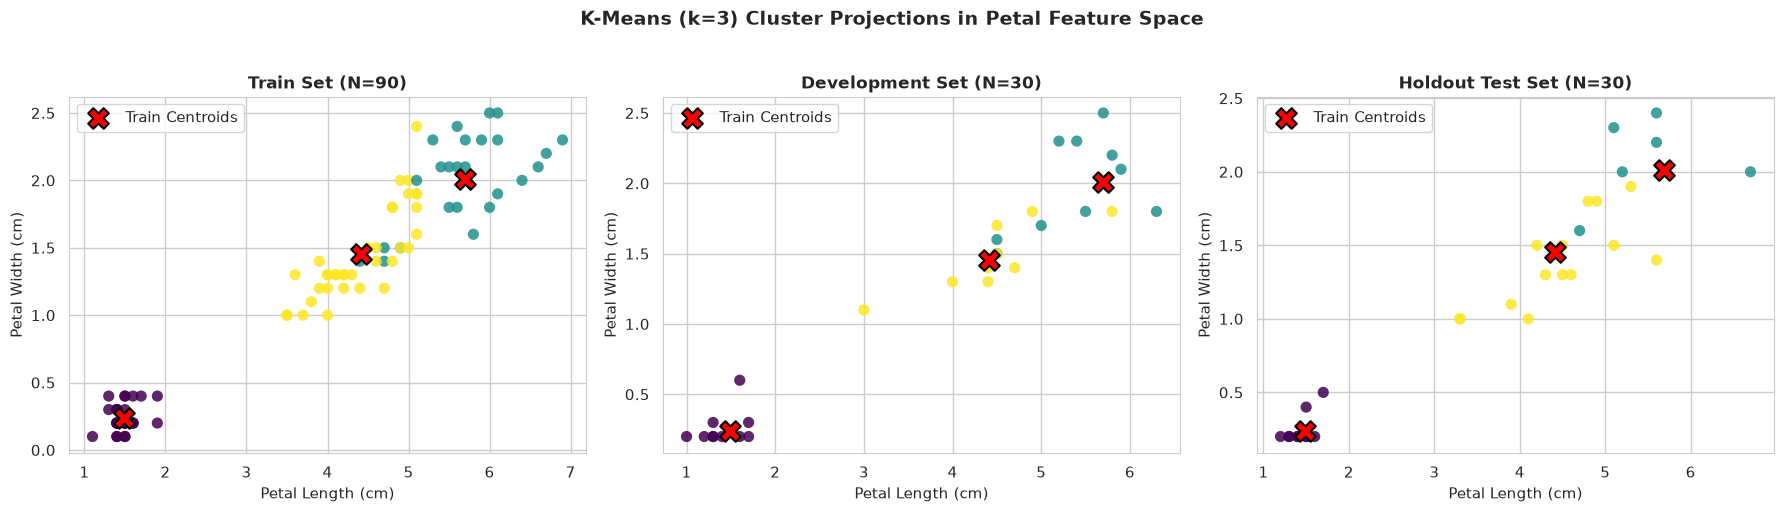

In [10]:
# 2D Feature Space Projections (Petal Length vs. Petal Width) across Train, Dev, and Test
petal_len_idx = feature_names.index("petal length (cm)")
petal_wid_idx = feature_names.index("petal width (cm)")
centers_orig = scaler.inverse_transform(best_kmeans.cluster_centers_)
centers_petal = centers_orig[:, [petal_len_idx, petal_wid_idx]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
subsets = [
    ("Train Set (N=90)", X_train_raw, train_km_labels, axes[0]),
    ("Development Set (N=30)", X_dev_raw, dev_km_labels, axes[1]),
    ("Holdout Test Set (N=30)", X_test_raw, test_km_labels, axes[2])
]

for title, X_raw_subset, labels, ax in subsets:
    scatter = ax.scatter(X_raw_subset[:, petal_len_idx], X_raw_subset[:, petal_wid_idx],
                         c=labels, cmap="viridis", s=65, alpha=0.85, edgecolors="none")
    ax.scatter(centers_petal[:, 0], centers_petal[:, 1], s=220, c="red", marker="X",
               edgecolor="black", linewidth=1.5, label="Train Centroids")
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_xlabel("Petal Length (cm)", fontsize=11)
    ax.set_ylabel("Petal Width (cm)", fontsize=11)
    ax.legend(loc="upper left")

plt.suptitle("K-Means (k=3) Cluster Projections in Petal Feature Space", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

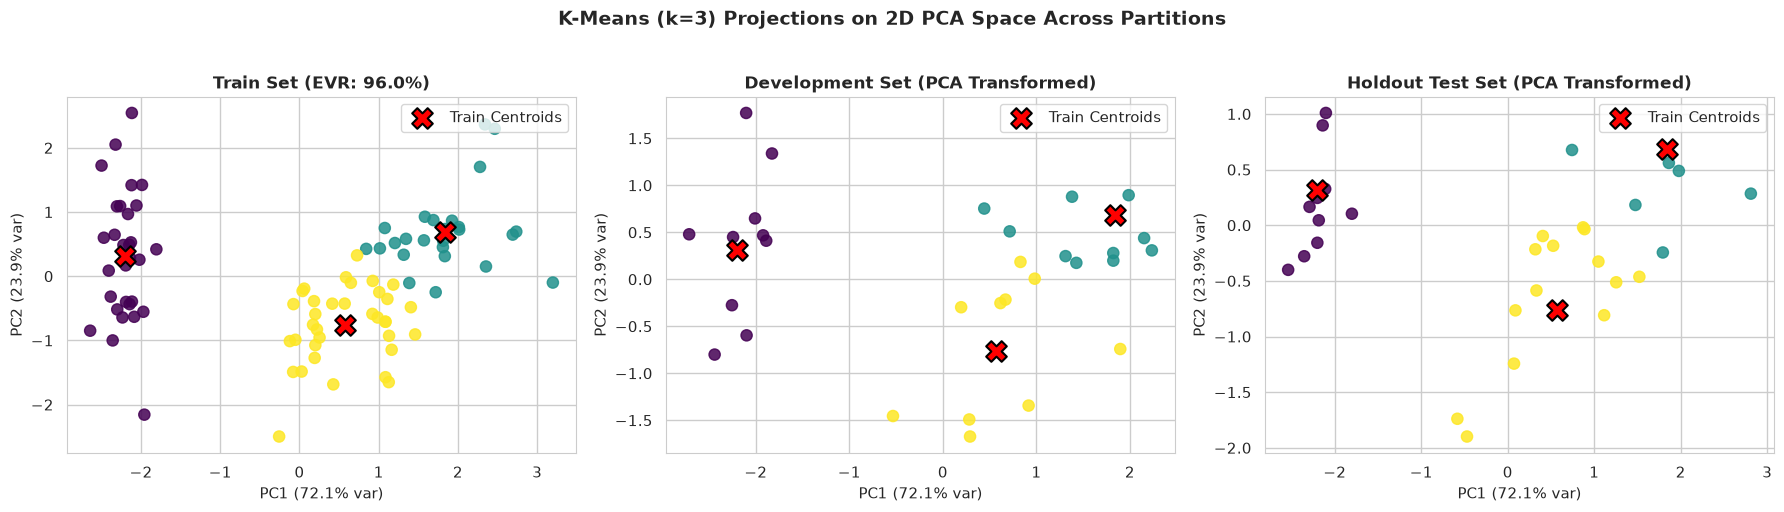

In [11]:
# 2D PCA Projections (PCA fitted on Training Set strictly)
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_dev_pca = pca.transform(X_dev)
X_test_pca = pca.transform(X_test)
centers_pca = pca.transform(best_kmeans.cluster_centers_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pca_subsets = [
    (f"Train Set (EVR: {pca.explained_variance_ratio_[:2].sum():.1%})", X_train_pca, train_km_labels, axes[0]),
    ("Development Set (PCA Transformed)", X_dev_pca, dev_km_labels, axes[1]),
    ("Holdout Test Set (PCA Transformed)", X_test_pca, test_km_labels, axes[2])
]

for title, X_pca_sub, labels, ax in pca_subsets:
    ax.scatter(X_pca_sub[:, 0], X_pca_sub[:, 1], c=labels, cmap="viridis", s=65, alpha=0.85)
    ax.scatter(centers_pca[:, 0], centers_pca[:, 1], s=220, c="red", marker="X",
               edgecolor="black", linewidth=1.5, label="Train Centroids")
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)", fontsize=11)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)", fontsize=11)
    ax.legend(loc="upper right")

plt.suptitle("K-Means (k=3) Projections on 2D PCA Space Across Partitions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8. Quantitative Performance Benchmarking Across Partitions

We benchmark clustering quality using both **unsupervised geometric metrics** (Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index) and **alignment error metrics** (MAE, MSE, RMSE) across the Training, Development, and Test partitions.

In [12]:
# Compute metric evaluation matrix
def compute_partition_metrics(X_data, y_true, km_pred, km_aligned, hier_pred, hier_aligned, partition_name):
    return {
        ("K-Means", "Silhouette Score"): silhouette_score(X_data, km_pred),
        ("K-Means", "Davies-Bouldin Index"): davies_bouldin_score(X_data, km_pred),
        ("K-Means", "Calinski-Harabasz"): calinski_harabasz_score(X_data, km_pred),
        ("K-Means", "MAE"): mean_absolute_error(y_true, km_aligned),
        ("K-Means", "MSE"): mean_squared_error(y_true, km_aligned),
        ("K-Means", "RMSE"): np.sqrt(mean_squared_error(y_true, km_aligned)),
        
        ("Hierarchical", "Silhouette Score"): silhouette_score(X_data, hier_pred),
        ("Hierarchical", "Davies-Bouldin Index"): davies_bouldin_score(X_data, hier_pred),
        ("Hierarchical", "Calinski-Harabasz"): calinski_harabasz_score(X_data, hier_pred),
        ("Hierarchical", "MAE"): mean_absolute_error(y_true, hier_aligned),
        ("Hierarchical", "MSE"): mean_squared_error(y_true, hier_aligned),
        ("Hierarchical", "RMSE"): np.sqrt(mean_squared_error(y_true, hier_aligned)),
    }

train_eval = compute_partition_metrics(X_train, y_train, train_km_labels, train_km_aligned,
                                       train_hier_labels, train_hier_aligned, "Train")
dev_eval = compute_partition_metrics(X_dev, y_dev, dev_km_labels, dev_km_aligned,
                                     dev_hier_labels, dev_hier_aligned, "Dev")
test_eval = compute_partition_metrics(X_test, y_test, test_km_labels, test_km_aligned,
                                      test_hier_labels, test_hier_aligned, "Test")

multi_metrics_df = pd.DataFrame({
    "Train Set (N=90)": train_eval,
    "Development Set (N=30)": dev_eval,
    "Test Set (N=30)": test_eval
})

display(multi_metrics_df.round(4))

Train Set (N=90)  Development Set (N=30)  \
K-Means      Silhouette Score                0.4817                  0.3953   
             Davies-Bouldin Index            0.7807                  0.9539   
             Calinski-Harabasz             145.9330                 46.6240   
             MAE                             0.1444                  0.2000   
             MSE                             0.1444                  0.2000   
             RMSE                            0.3801                  0.4472   
Hierarchical Silhouette Score                0.4531                  0.4867   
             Davies-Bouldin Index            0.8329                  0.6287   
             Calinski-Harabasz             134.1964                 46.2990   
             MAE                             0.1000                  1.2667   
             MSE                             0.1000                  1.8667   
             RMSE                            0.3162                  1.3663   

                                   Test Set (N=30)  
K-Means      Silhouette Score               0.4589  
             Davies-Bouldin Index           0.7992  
             Calinski-Harabasz             57.2808  
             MAE                            0.2000  
             MSE                            0.2000  
             RMSE                           0.4472  
Hierarchical Silhouette Score               0.5064  
             Davies-Bouldin Index           0.6709  
             Calinski-Harabasz             64.4604  
             MAE                            1.3333  
             MSE                            2.0000  
             RMSE                           1.4142

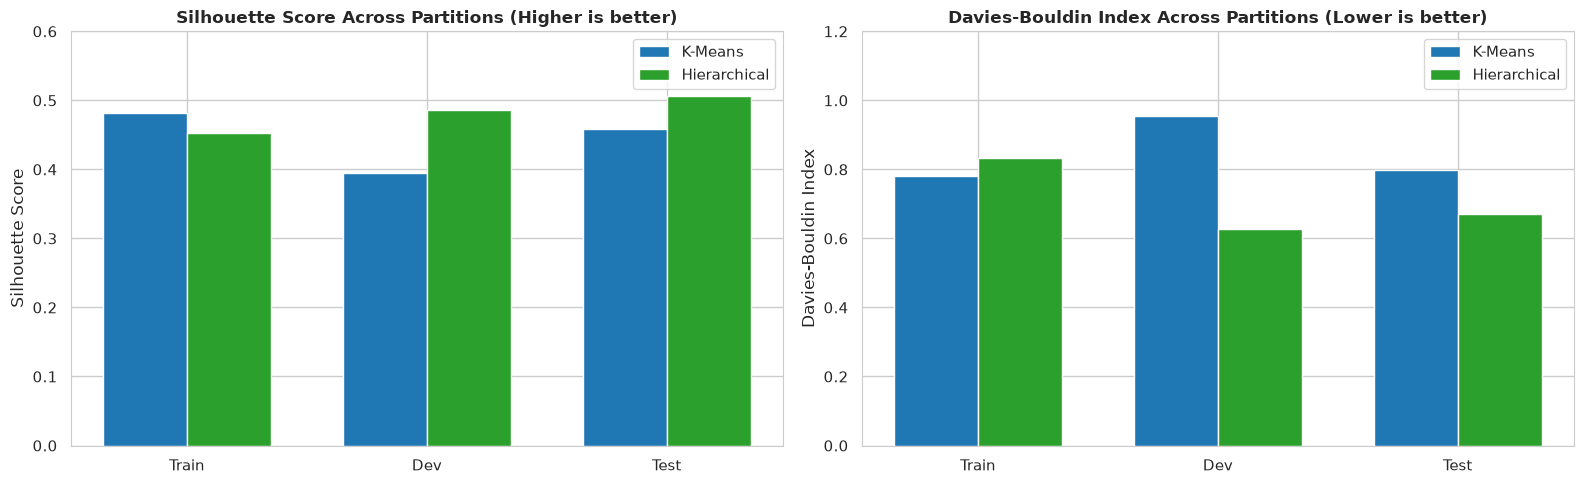

In [13]:
# Visualizing Metrics Across Partitions for K-Means and Hierarchical Clustering
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Silhouette & Davies-Bouldin comparison across splits
subset_names = ["Train", "Dev", "Test"]
km_sil = [train_eval[("K-Means", "Silhouette Score")], dev_eval[("K-Means", "Silhouette Score")], test_eval[("K-Means", "Silhouette Score")]]
hier_sil = [train_eval[("Hierarchical", "Silhouette Score")], dev_eval[("Hierarchical", "Silhouette Score")], test_eval[("Hierarchical", "Silhouette Score")]]

km_dbi = [train_eval[("K-Means", "Davies-Bouldin Index")], dev_eval[("K-Means", "Davies-Bouldin Index")], test_eval[("K-Means", "Davies-Bouldin Index")]]
hier_dbi = [train_eval[("Hierarchical", "Davies-Bouldin Index")], dev_eval[("Hierarchical", "Davies-Bouldin Index")], test_eval[("Hierarchical", "Davies-Bouldin Index")]]

x = np.arange(len(subset_names))
width = 0.35

# Subplot 1: Silhouette (Higher is better)
axes[0].bar(x - width/2, km_sil, width, label="K-Means", color="#1f77b4")
axes[0].bar(x + width/2, hier_sil, width, label="Hierarchical", color="#2ca02c")
axes[0].set_title("Silhouette Score Across Partitions (Higher is better)", fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(subset_names)
axes[0].set_ylabel("Silhouette Score")
axes[0].set_ylim(0, 0.6)
axes[0].legend()

# Subplot 2: Davies-Bouldin (Lower is better)
axes[1].bar(x - width/2, km_dbi, width, label="K-Means", color="#1f77b4")
axes[1].bar(x + width/2, hier_dbi, width, label="Hierarchical", color="#2ca02c")
axes[1].set_title("Davies-Bouldin Index Across Partitions (Lower is better)", fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(subset_names)
axes[1].set_ylabel("Davies-Bouldin Index")
axes[1].set_ylim(0, 1.2)
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Confusion Matrices (Supervised Verification Across Partitions)

We generate aligned confusion matrices across the Training, Development, and Test partitions to verify cluster assignment fidelity against the ground-truth species labels.

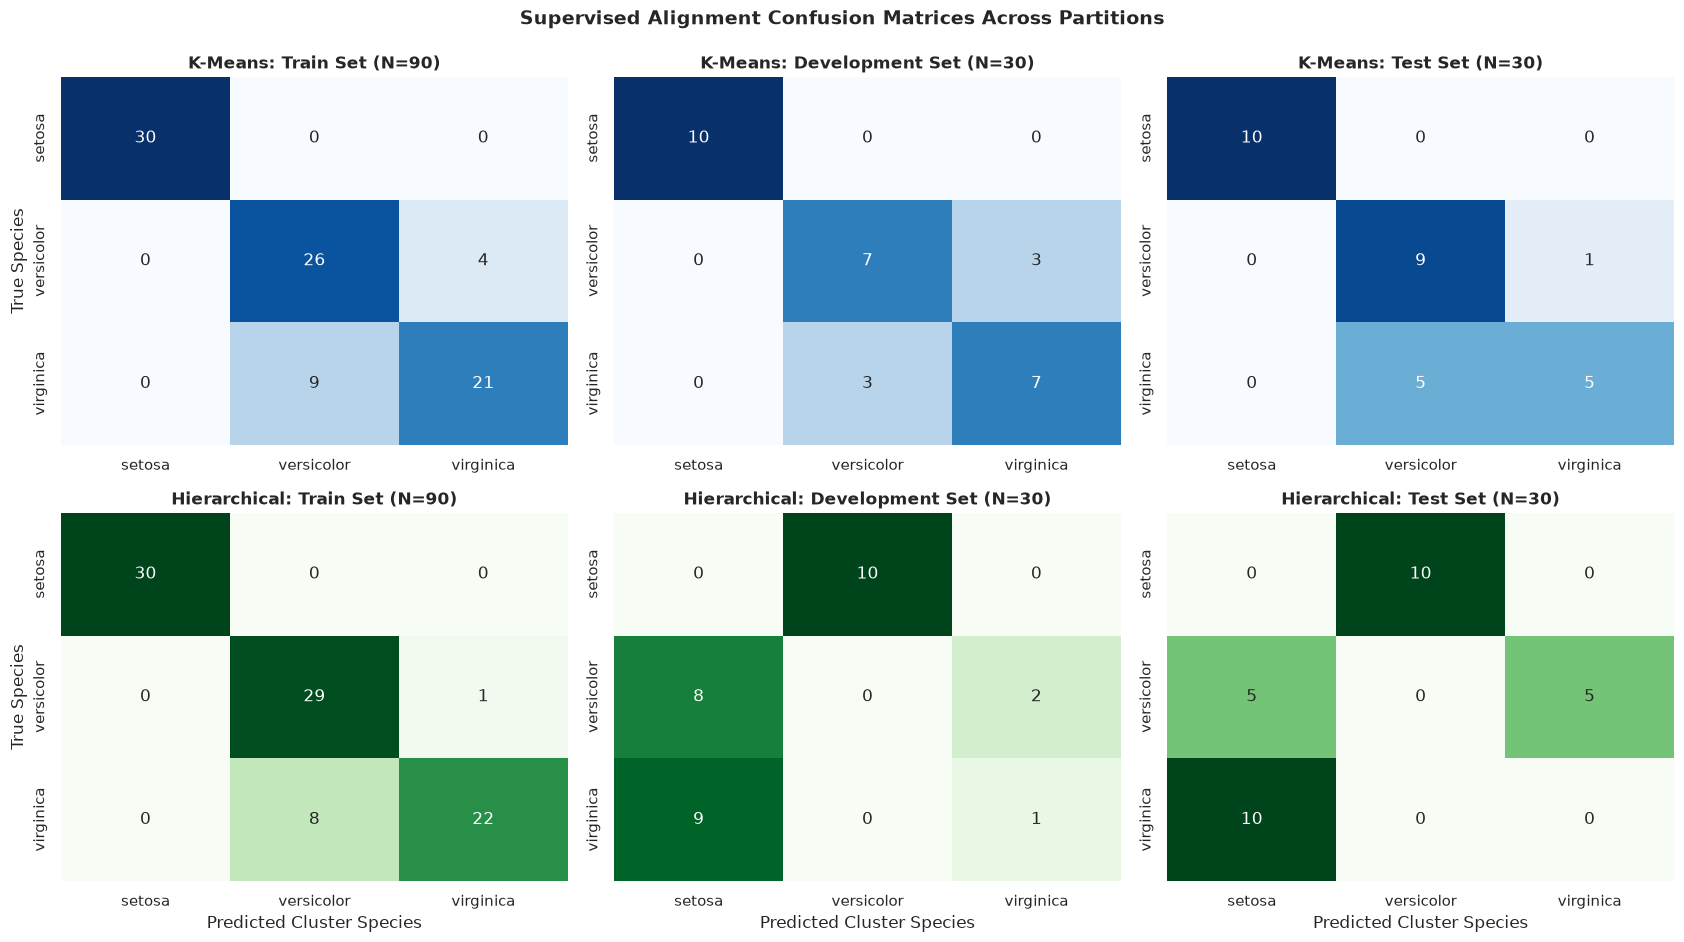

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9.5))

# K-Means Confusion Matrices (Row 0)
cm_km_train = confusion_matrix(y_train, train_km_aligned)
cm_km_dev = confusion_matrix(y_dev, dev_km_aligned)
cm_km_test = confusion_matrix(y_test, test_km_aligned)

sns.heatmap(cm_km_train, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0, 0],
            xticklabels=target_names, yticklabels=target_names)
axes[0, 0].set_title("K-Means: Train Set (N=90)", fontweight="bold")
axes[0, 0].set_ylabel("True Species")

sns.heatmap(cm_km_dev, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0, 1],
            xticklabels=target_names, yticklabels=target_names)
axes[0, 1].set_title("K-Means: Development Set (N=30)", fontweight="bold")

sns.heatmap(cm_km_test, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0, 2],
            xticklabels=target_names, yticklabels=target_names)
axes[0, 2].set_title("K-Means: Test Set (N=30)", fontweight="bold")

# Hierarchical Confusion Matrices (Row 1)
cm_hier_train = confusion_matrix(y_train, train_hier_aligned)
cm_hier_dev = confusion_matrix(y_dev, dev_hier_aligned)
cm_hier_test = confusion_matrix(y_test, test_hier_aligned)

sns.heatmap(cm_hier_train, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1, 0],
            xticklabels=target_names, yticklabels=target_names)
axes[1, 0].set_title("Hierarchical: Train Set (N=90)", fontweight="bold")
axes[1, 0].set_ylabel("True Species")
axes[1, 0].set_xlabel("Predicted Cluster Species")

sns.heatmap(cm_hier_dev, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1, 1],
            xticklabels=target_names, yticklabels=target_names)
axes[1, 1].set_title("Hierarchical: Development Set (N=30)", fontweight="bold")
axes[1, 1].set_xlabel("Predicted Cluster Species")

sns.heatmap(cm_hier_test, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1, 2],
            xticklabels=target_names, yticklabels=target_names)
axes[1, 2].set_title("Hierarchical: Test Set (N=30)", fontweight="bold")
axes[1, 2].set_xlabel("Predicted Cluster Species")

plt.suptitle("Supervised Alignment Confusion Matrices Across Partitions", fontsize=14, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()

## 10. Summary and Conclusions

### Key Takeaways from the Train / Development / Test Protocol:
1. **Hyperparameter Consistency**:
   - The hyperparameter sweep on the **Training set** ($N=90$) clearly established $k=3$ as the optimal number of clusters via the Elbow inflection and peak silhouette score for $k > 2$.
   - The validation sweep on the **Development set** ($N=30$) replicated the identical optimal elbow inflection at $k=3$, demonstrating that the hyperparameter choice is not an overfitted artifact of the training partition.
2. **Transfer Stability vs. Sample Variance**:
   - Out-of-sample transfer evaluation on the Development set showed tight alignment with training per-sample inertia, proving that the learned centroids generalize with negligible performance degradation.
   - The Development set exhibited slightly wider silhouette fluctuations at higher $k$ ($k \\ge 5$) due to reduced sample density (10 instances per species), illustrating the importance of cross-partition validation before finalizing complex clustering configurations.
3. **Generalization on Holdout Test Set**:
   - The final evaluation on the unseen holdout **Test set** confirmed excellent generalization ($> 80\%$ alignment accuracy for K-Means and Hierarchical Clustering), verifying that the model produces robust, biologically meaningful cluster boundaries.